# PRM-as-a-Judge Quick Start

Run the repository's three real robot-rollout examples with the public Robo-Dopamine checkpoint, inspect the generated metrics and curves, and open the interactive report.

Use a **Python 3.10** kernel with an NVIDIA GPU. Run the cells from top to bottom. The dependency-install cell is optional when the environment is already prepared.

## 1. Locate the repository

The notebook can be launched from the repository root or from the `getting_started` directory.

In [1]:
from pathlib import Path
import os
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'eval/run_eval.sh').is_file():
            return candidate
    raise FileNotFoundError('Run this notebook from inside a PRM-as-a-Judge checkout.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
if str(REPO_ROOT / 'eval') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'eval'))
print(f'Repository: {REPO_ROOT}')
print(f'Python: {sys.version.split()[0]} ({sys.executable})')

Repository: /share/project/lyy/judge_model/code/PRM-as-a-Judge
Python: 3.10.20 (/share/project/lyy/env/prm-as-a-judge-quickstart-py310-20260718/bin/python)


## 2. Install dependencies (optional)

Set `INSTALL_DEPENDENCIES = True` for a new Python 3.10 environment. Skip this cell when the Dopamine and notebook dependencies are already installed.

In [2]:
import subprocess

INSTALL_DEPENDENCIES = False
if INSTALL_DEPENDENCIES:
    constraint = REPO_ROOT / 'constraints/dopamine-cu128-py310.txt'
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-e', '.[dopamine,notebook]',
        '-c', str(constraint),
    ], cwd=REPO_ROOT)
else:
    print('Dependency installation skipped.')

Dependency installation skipped.


## 3. Configure the checkpoint, GPU, manifest, and output directory

`MODEL_SOURCE` may be either a Hugging Face model ID or an existing local checkpoint directory. You can also set the `PRM_CHECKPOINT` environment variable before launching Jupyter.

In [3]:
# MODEL_SOURCE = os.environ.get(
#     'PRM_CHECKPOINT',
#     'tanhuajie2001/Robo-Dopamine-GRM-2.0-8B-Preview',
# )
MODEL_SOURCE = "/share/project/lyy/models/tanhuajie2001/Robo-Dopamine-GRM-2.0-8B-Preview"
GPU = os.environ.get('PRM_GPU', '0')
MANIFEST = REPO_ROOT / 'eval/examples/manifest_demo_cases.jsonl'
OUTPUT_ROOT = REPO_ROOT / 'eval/results/notebook_quickstart'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f'Model source: {MODEL_SOURCE}')
print(f'GPU: {GPU}')
print(f'Manifest: {MANIFEST}')
print(f'Output root: {OUTPUT_ROOT}')

Model source: /share/project/lyy/models/tanhuajie2001/Robo-Dopamine-GRM-2.0-8B-Preview
GPU: 0
Manifest: /share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/examples/manifest_demo_cases.jsonl
Output root: /share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/results/notebook_quickstart


## 4. Check CUDA and resolve the checkpoint

A Hugging Face model ID is downloaded to the standard local cache. A local directory is used directly.

In [4]:
gpu_check = subprocess.run(
    ['nvidia-smi', '--query-gpu=index,name,memory.total', '--format=csv,noheader'],
    text=True, capture_output=True, check=False,
)
if gpu_check.returncode != 0:
    raise RuntimeError('nvidia-smi failed. Run this notebook on a machine with an NVIDIA GPU.')
print(gpu_check.stdout.strip())

local_candidate = Path(MODEL_SOURCE).expanduser()
if local_candidate.is_dir():
    PRM_PATH = local_candidate.resolve()
else:
    from huggingface_hub import snapshot_download
    PRM_PATH = Path(snapshot_download(repo_id=MODEL_SOURCE)).resolve()
print(f'Checkpoint: {PRM_PATH}')

0, NVIDIA H100 80GB HBM3, 81559 MiB
Checkpoint: /share/project/lyy/models/tanhuajie2001/Robo-Dopamine-GRM-2.0-8B-Preview


## 5. Preview and validate the three bundled cases

The manifest loader resolves media paths relative to the manifest file and checks the supported camera-field layout.

In [5]:
from prm_judge.manifest import load_manifest

cases = load_manifest(MANIFEST)
assert len(cases) == 3, f'Expected 3 cases, found {len(cases)}'
preview = []
for case in cases:
    missing = [str(path) for path in case.videos.values() if not path.is_file()]
    if case.goal_image is not None and not case.goal_image.is_file():
        missing.append(str(case.goal_image))
    if missing:
        raise FileNotFoundError(f'{case.case_id}: missing {missing}')
    preview.append({
        'case_id': case.case_id,
        'task': case.task,
        'views': list(case.videos),
        'goal_image': str(case.goal_image) if case.goal_image else None,
    })
preview

[{'case_id': 'arrange_flowers_episode0',
  'task': 'Insert the three flowers on the table into the vase one by one.',
  'views': ['video', 'wrist_video'],
  'goal_image': '/share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/examples/arrange_flowers.jpg'},
 {'case_id': 'arrange_flowers_episode1',
  'task': 'Insert the three flowers on the table into the vase one by one.',
  'views': ['video', 'wrist_video'],
  'goal_image': '/share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/examples/arrange_flowers.jpg'},
 {'case_id': 'set_the_plates_episode0',
  'task': 'Place the three plates onto the plate rack one by one.',
  'views': ['video', 'wrist_video'],
  'goal_image': '/share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/examples/set_the_plates.jpg'}]

## 6. Run the full three-case evaluation

This cell calls the repository's existing shell runner with explicit settings and enables report generation. Depending on the GPU, this can take several minutes.

In [6]:
import time

started_at = time.time()
run_env = os.environ.copy()
run_env.update({
    'MANIFEST': str(MANIFEST),
    'PRM_PATH': str(PRM_PATH),
    'GPUS': GPU,
    'OUTPUT_ROOT': str(OUTPUT_ROOT),
    'VISUALIZE': '1',
    'PYTHON': sys.executable,
})
subprocess.run(['bash', 'eval/run_eval.sh'], cwd=REPO_ROOT, env=run_env, check=True)

new_runs = [
    path for path in OUTPUT_ROOT.glob('run_*')
    if path.is_dir() and path.stat().st_mtime >= started_at - 2
]
if not new_runs:
    raise RuntimeError(f'No new run directory was created under {OUTPUT_ROOT}')
RUN_ROOT = max(new_runs, key=lambda path: path.stat().st_mtime)
print(f'Run root: {RUN_ROOT}')

[INFO] PRM-as-a-Judge v1.5
[INFO] prm=dopamine eval_mode=incremental frame_interval=72 gpus=0
[INFO] smoothing=weighted_window smoothing_weights=0.1,0.2,0.4,0.2,0.1 visualize=1
INFO 07-20 10:01:35 [__init__.py:216] Automatically detected platform cuda.
Loading model from /share/project/lyy/models/tanhuajie2001/Robo-Dopamine-GRM-2.0-8B-Preview ...
INFO 07-20 10:01:42 [utils.py:233] non-default args: {'trust_remote_code': True, 'max_model_len': 8192, 'enable_prefix_caching': True, 'disable_log_stats': True, 'limit_mm_per_prompt': {'image': 8}, 'model': '/share/project/lyy/models/tanhuajie2001/Robo-Dopamine-GRM-2.0-8B-Preview'}
INFO 07-20 10:01:42 [model.py:547] Resolved architecture: Qwen3VLForConditionalGeneration
INFO 07-20 10:01:42 [model.py:1510] Using max model len 8192


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
`torch_dtype` is deprecated! Use `dtype` instead!


INFO 07-20 10:01:45 [scheduler.py:205] Chunked prefill is enabled with max_num_batched_tokens=16384.
(EngineCore_DP0 pid=223479) INFO 07-20 10:01:49 [core.py:644] Waiting for init message from front-end.
(EngineCore_DP0 pid=223479) INFO 07-20 10:01:49 [core.py:77] Initializing a V1 LLM engine (v0.11.0) with config: model='/share/project/lyy/models/tanhuajie2001/Robo-Dopamine-GRM-2.0-8B-Preview', speculative_config=None, tokenizer='/share/project/lyy/models/tanhuajie2001/Robo-Dopamine-GRM-2.0-8B-Preview', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=8192, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_fallback=False, disable_any_whitespace=Fa

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  50% Completed | 1/2 [00:11<00:11, 11.29s/it]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:29<00:00, 15.62s/it]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:29<00:00, 14.97s/it]
(EngineCore_DP0 pid=223479) 


(EngineCore_DP0 pid=223479) INFO 07-20 10:02:26 [default_loader.py:267] Loading weights took 30.30 seconds
(EngineCore_DP0 pid=223479) INFO 07-20 10:02:26 [gpu_model_runner.py:2653] Model loading took 16.9678 GiB and 30.774242 seconds
(EngineCore_DP0 pid=223479) INFO 07-20 10:02:26 [gpu_model_runner.py:3344] Encoder cache will be initialized with a budget of 151250 tokens, and profiled with 1 video items of the maximum feature size.
(EngineCore_DP0 pid=223479) INFO 07-20 10:02:42 [backends.py:548] Using cache directory: /root/.cache/vllm/torch_compile_cache/2f849227e1/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=223479) INFO 07-20 10:02:42 [backends.py:559] Dynamo bytecode transform time: 9.00 s
(EngineCore_DP0 pid=223479) INFO 07-20 10:02:46 [backends.py:164] Directly load the compiled graph(s) for dynamic shape from the cache, took 3.269 s
(EngineCore_DP0 pid=223479) INFO 07-20 10:02:47 [monitor.py:34] torch.compile takes 9.00 s in total
(EngineCore_DP0 pid=223479) 

...

Done. Results saved to /share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/results/notebook_quickstart/run_260720_100124/demo_cases/cogact/arrange_flowers/arrange_flowers_episode0/26-07-20-10-03-00_incremental_mode_Insert_the_three_flowers_on_the_table_into_the_vase_one_by_one_/pred_vllm.json
Generating visualization video...
Generating video with 30 frames...
Video saved to: /share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/results/notebook_quickstart/run_260720_100124/demo_cases/cogact/arrange_flowers/arrange_flowers_episode0/26-07-20-10-03-00_incremental_mode_Insert_the_three_flowers_on_the_table_into_the_vase_one_by_one_/reward_vis.mp4
[1/3] arrange_flowers_episode0: ok
[WARN] Frame count mismatch among cameras: [5838, 5814, 5814]. Using the shortest length 5814.
Frames: 5814, Int: 72, Mode: incremental, Indices: 82
Using Goal Image: /share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/examples/arrange_flowers.jpg
Running inference on 81 samples...


100%|██████████| 9/9 [00:37<00:00,  4.12s/it]


Done. Results saved to /share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/results/notebook_quickstart/run_260720_100124/demo_cases/spirit-v1.5/arrange_flowers/arrange_flowers_episode1/26-07-20-10-03-40_incremental_mode_Insert_the_three_flowers_on_the_table_into_the_vase_one_by_one_/pred_vllm.json
Generating visualization video...
Generating video with 82 frames...
Video saved to: /share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/results/notebook_quickstart/run_260720_100124/demo_cases/spirit-v1.5/arrange_flowers/arrange_flowers_episode1/26-07-20-10-03-40_incremental_mode_Insert_the_three_flowers_on_the_table_into_the_vase_one_by_one_/reward_vis.mp4
[2/3] arrange_flowers_episode1: ok
Frames: 10020, Int: 72, Mode: incremental, Indices: 141
Using Goal Image: /share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/examples/set_the_plates.jpg
Running inference on 140 samples...


100%|██████████| 14/14 [00:59<00:00,  4.24s/it]


Done. Results saved to /share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/results/notebook_quickstart/run_260720_100124/demo_cases/pi0.5/set_the_plates/set_the_plates_episode0/26-07-20-10-05-28_incremental_mode_Place_the_three_plates_onto_the_plate_rack_one_by_one_/pred_vllm.json
Generating visualization video...
Generating video with 141 frames...
Video saved to: /share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/results/notebook_quickstart/run_260720_100124/demo_cases/pi0.5/set_the_plates/set_the_plates_episode0/26-07-20-10-05-28_incremental_mode_Place_the_three_plates_onto_the_plate_rack_one_by_one_/reward_vis.mp4
[3/3] set_the_plates_episode0: ok
[VIS] curve_metrics_csv: /share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/results/notebook_quickstart/run_260720_100124/visualizations/curve_metrics.csv
[VIS] report_html: /share/project/lyy/judge_model/code/PRM-as-a-Judge/eval/results/notebook_quickstart/run_260720_100124/visualizations/report.html
[VIS] case_plots_dir: /

## 7. Inspect the summary, core metrics, and case plots

### Run summary

{'total_cases': 3,
 'processed_ok': 3,
 'processed_error': 0,
 'metrics': {'groups': [{'benchmark': 'demo_cases',
    'model': 'cogact',
    'task': 'arrange_flowers',
    'num_cases': 1,
    'M25': 1.0,
    'M50': 0.0,
    'M75': 0.0,
    'SR': 0.0,
    'MaxP': 0.255144418369267,
    'PPL': 0.13753413421557253,
    'CRA': 0.015934358275933997,
    'STR': 0.06896551724137931,
    'MDD': 0.07430711041243569,
    'Rec': 0.13692942675007347,
    'DRR': 1.0,
    'MaxP-F': 0.255144418369267,
    'SQS': 0.0,
    'FNS': 0.1275722091846335,
    'OAS': 0.2255144418369267},
   {'benchmark': 'demo_cases',
    'model': 'pi0.5',
    'task': 'set_the_plates',
    'num_cases': 1,
    'M25': 1.0,
    'M50': 1.0,
    'M75': 1.0,
    'SR': 1.0,
    'MaxP': 0.9960787462933742,
    'PPL': 0.5843509964384361,
    'CRA': 0.03503738815789805,
    'STR': 0.20714285714285716,
    'MDD': 0.20631617619638043,
    'Rec': 0.36497027205627863,
    'DRR': 1.0,
    'MaxP-F': 0.0,
    'SQS': 0.7402357103432773,
    'F

### Per-case curve metrics

[{'case_id': 'arrange_flowers_episode0',
  'task_name': 'arrange_flowers',
  'task': 'Insert the three flowers on the table into the vase one by one.',
  'benchmark': 'demo_cases',
  'prm_backend': 'dopamine',
  'policy_model': 'cogact',
  'label': '',
  'status': 'ok',
  'num_points': '29',
  'MaxP': '0.255144418369267',
  'M25': '1.0',
  'M50': '0.0',
  'M75': '0.0',
  'SR': '0.0',
  'PPL': '0.13753413421557253',
  'CRA': '0.015934358275933997',
  'STR': '0.06896551724137931',
  'MDD': '0.07430711041243569',
  'Rec': '0.13692942675007347',
  'DRR': '1.0'},
 {'case_id': 'arrange_flowers_episode1',
  'task_name': 'arrange_flowers',
  'task': 'Insert the three flowers on the table into the vase one by one.',
  'benchmark': 'demo_cases',
  'prm_backend': 'dopamine',
  'policy_model': 'spirit-v1.5',
  'label': '',
  'status': 'ok',
  'num_points': '81',
  'MaxP': '0.9175173351373569',
  'M25': '1.0',
  'M50': '1.0',
  'M75': '1.0',
  'SR': '0.0',
  'PPL': '0.6787752631652247',
  'CRA': '0

### Case plots (3)

**0001_arrange_flowers_episode0**

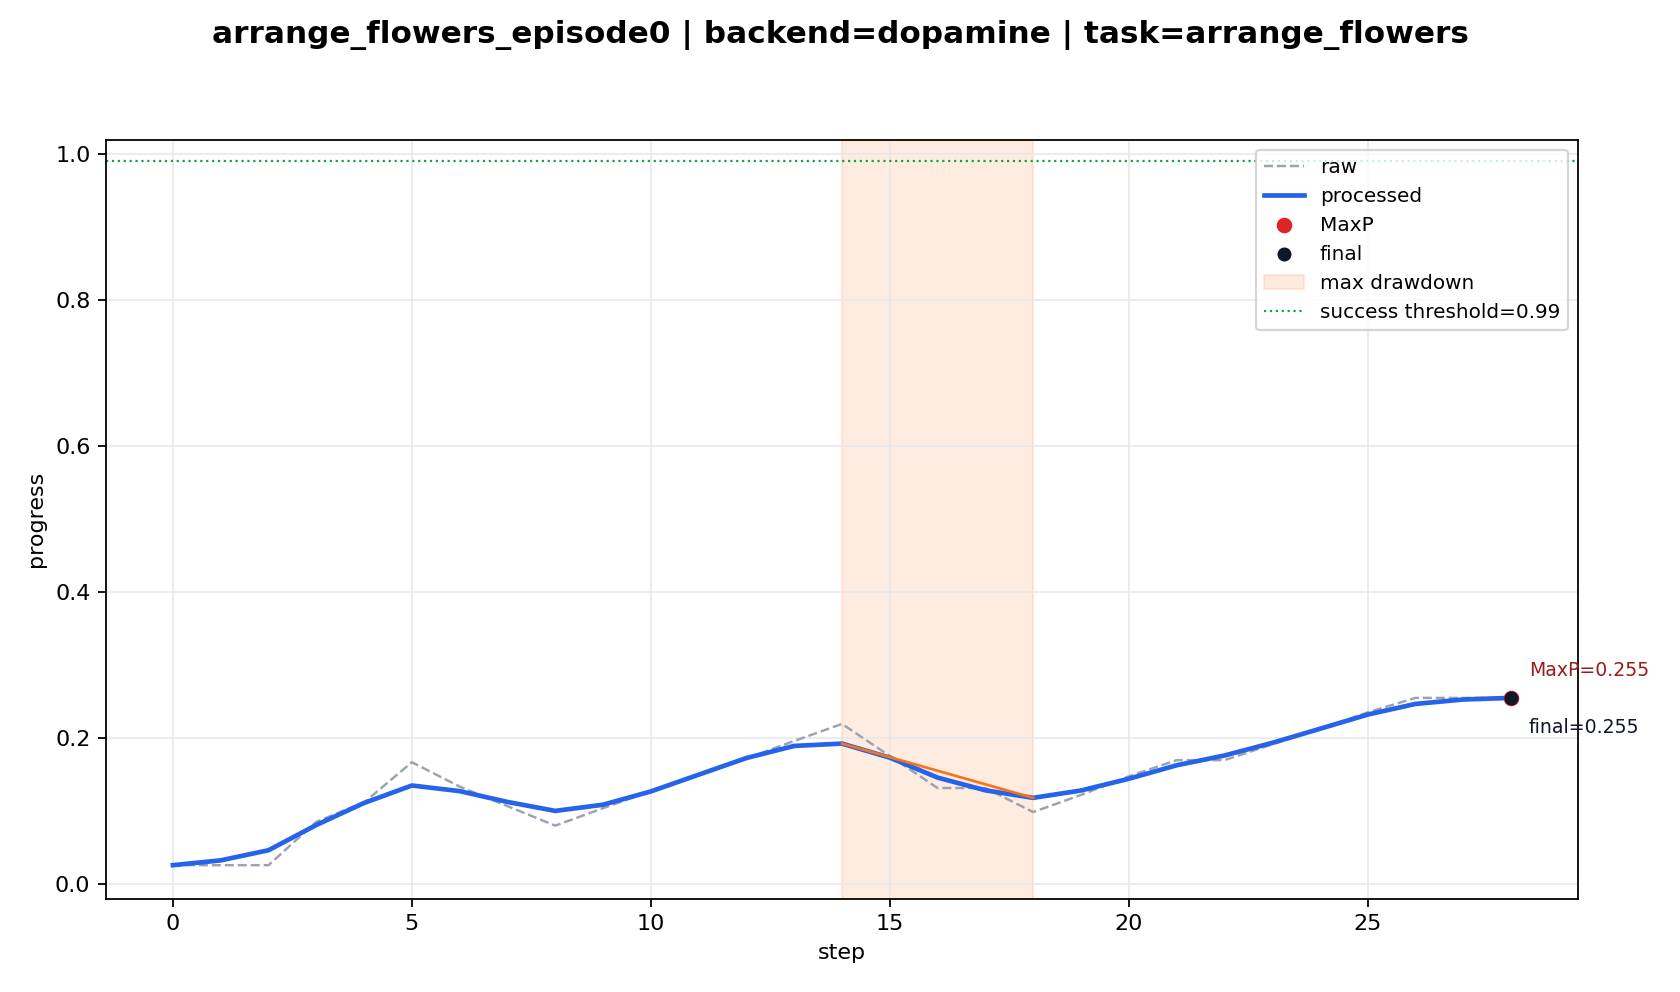

**0002_arrange_flowers_episode1**

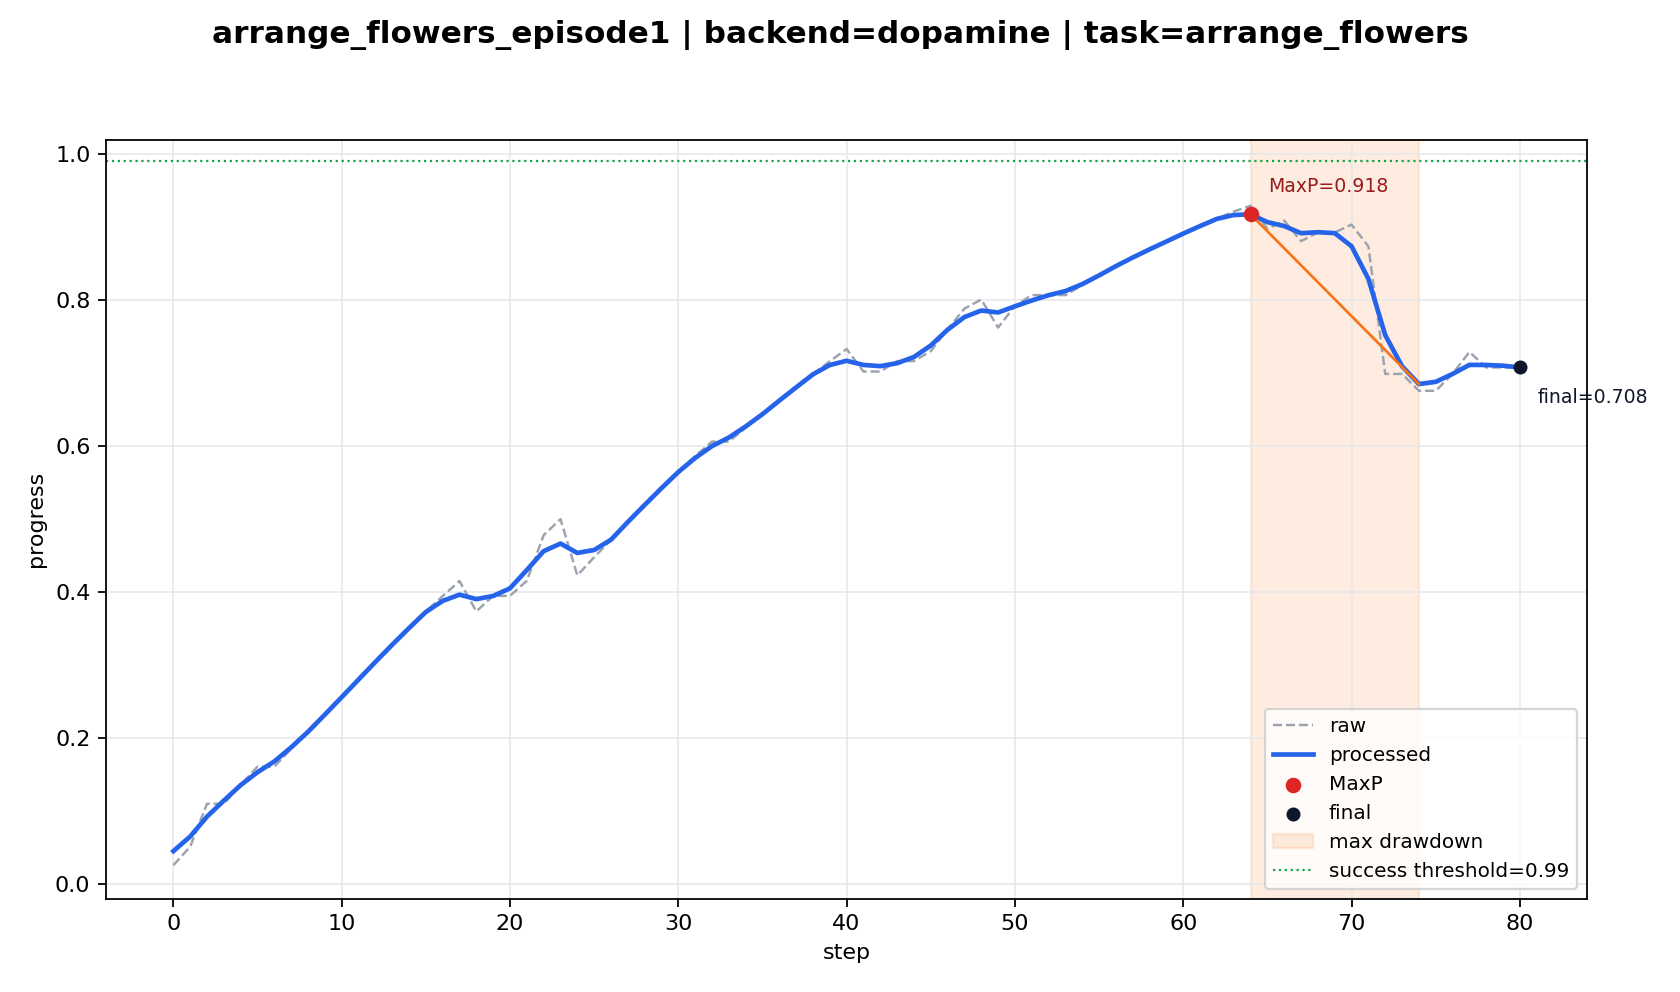

**0003_set_the_plates_episode0**

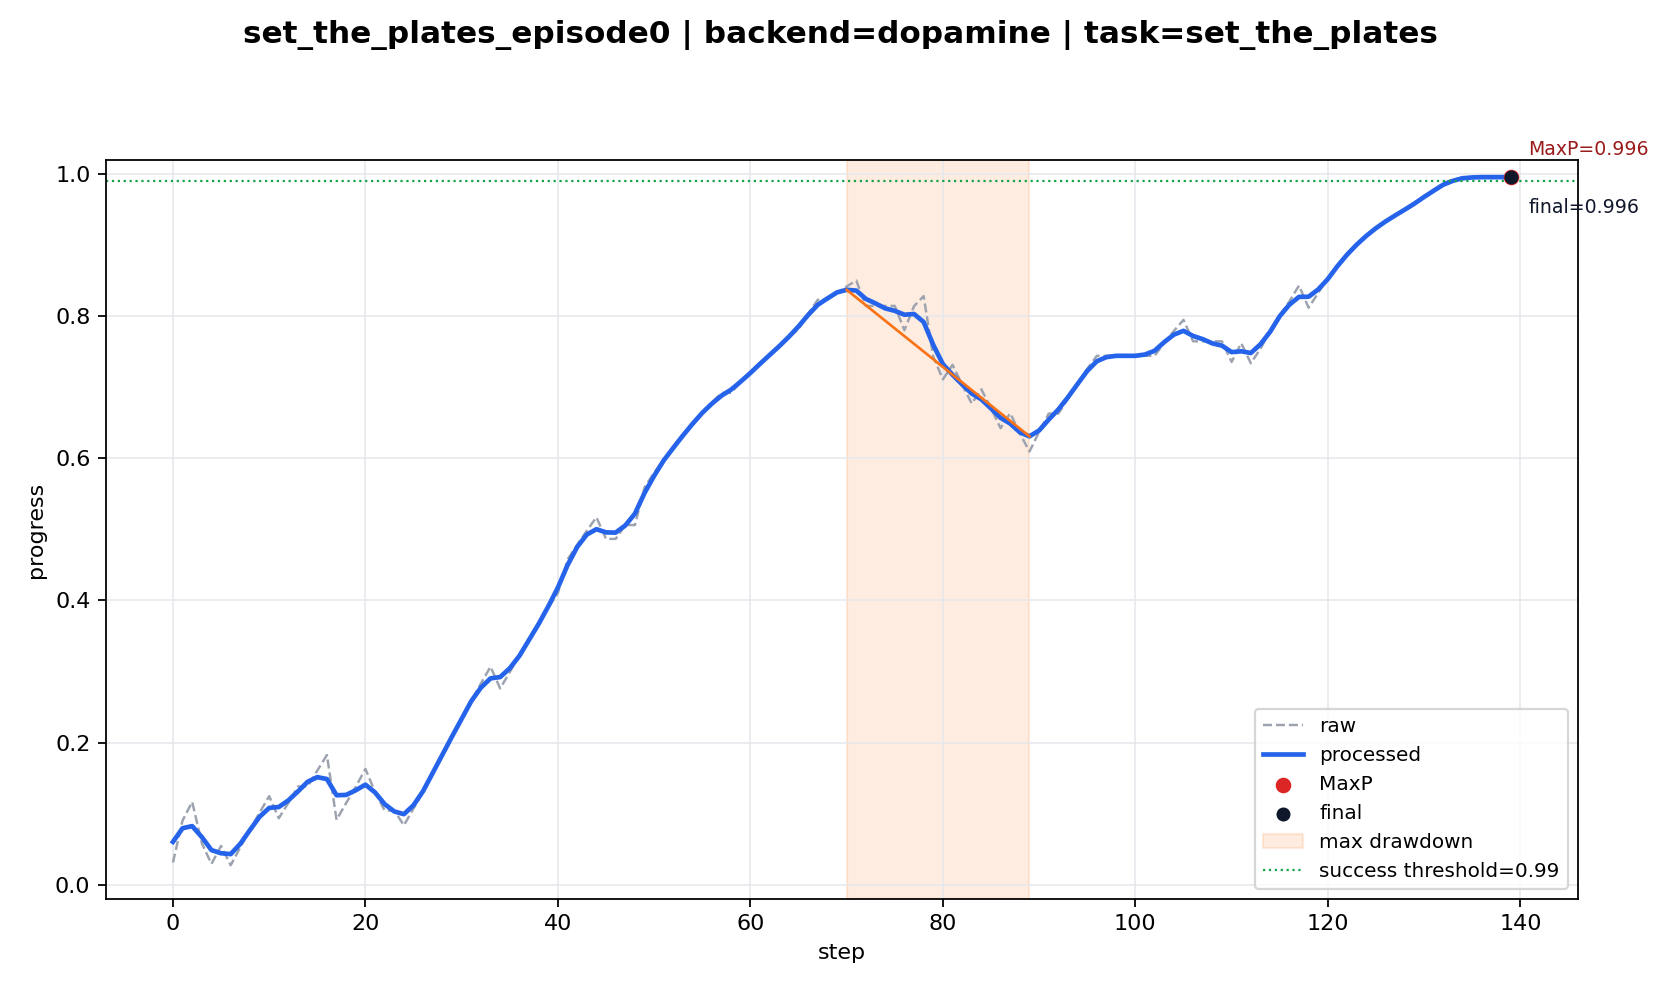

In [7]:
import csv
import json
from IPython.display import Image, Markdown, display

run_summary = json.loads((RUN_ROOT / 'run_summary.json').read_text(encoding='utf-8'))
display(Markdown('### Run summary'))
display(run_summary)

metrics_path = RUN_ROOT / 'visualizations/curve_metrics.csv'
with metrics_path.open(encoding='utf-8', newline='') as handle:
    metric_rows = list(csv.DictReader(handle))
display(Markdown('### Per-case curve metrics'))
display(metric_rows)

plots = sorted((RUN_ROOT / 'visualizations/cases').glob('*.png'))
display(Markdown(f'### Case plots ({len(plots)})'))
for plot in plots:
    display(Markdown(f'**{plot.stem}**'))
    display(Image(filename=str(plot), width=900))

## 8. Start the interactive report server

Re-running this cell closes the previous notebook-owned server before starting a new one. The server binds to loopback and chooses an available port automatically.

In [8]:
import threading
from IPython.display import HTML, display
from prm_judge.serve import create_report_server

if '_report_server' in globals() and _report_server is not None:
    _report_server.shutdown()
    _report_server.server_close()
    if '_report_thread' in globals():
        _report_thread.join(timeout=5)

_report_server = create_report_server(RUN_ROOT, host='127.0.0.1', port=0)
_report_thread = threading.Thread(target=_report_server.serve_forever, daemon=True)
_report_thread.start()
report_port = _report_server.server_address[1]
report_url = f'http://127.0.0.1:{report_port}/report.html'
display(HTML(f'<a href="{report_url}" target="_blank">Open the full interactive report</a>'))
print(report_url)

http://127.0.0.1:38921/report.html
